            variance_metric performance_metric  pearson_r      pearson_p  \
0          grammer_variance           total_f1   0.547262   3.255208e-44   
1          grammer_variance       total_recall   0.466874   4.540638e-31   
2          grammer_variance    total_precision   0.175074   3.712654e-05   
3  w2v_total_variance_trace           total_f1   0.234300   2.779055e-08   
4  w2v_total_variance_trace       total_recall   0.755448  1.634870e-102   
5  w2v_total_variance_trace    total_precision  -0.498132   9.060255e-36   

   spearman_r    spearman_p  
0    0.565850  8.648722e-48  
1    0.472656  6.667732e-32  
2    0.094555  2.673126e-02  
3   -0.003258  9.392800e-01  
4    0.640944  7.760868e-65  
5   -0.629169  7.503734e-62  


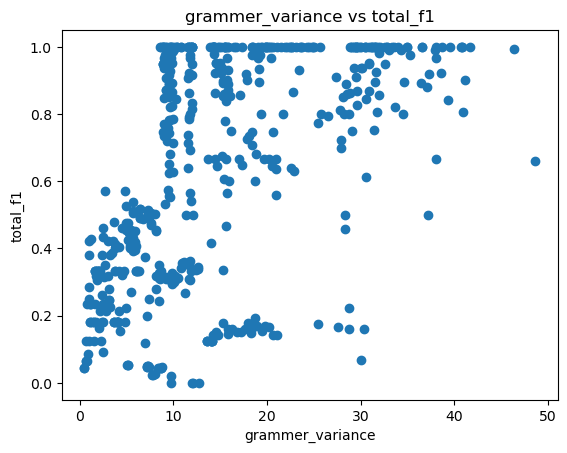

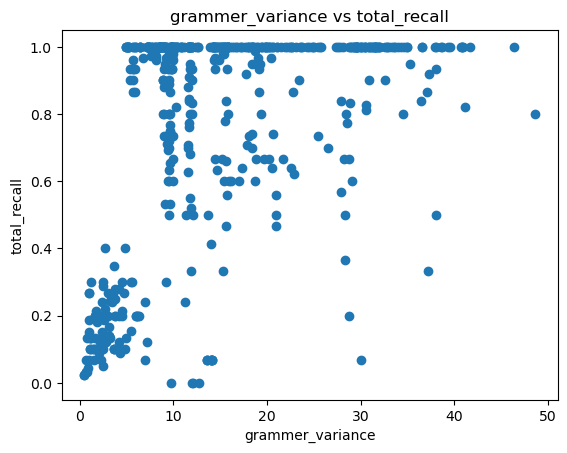

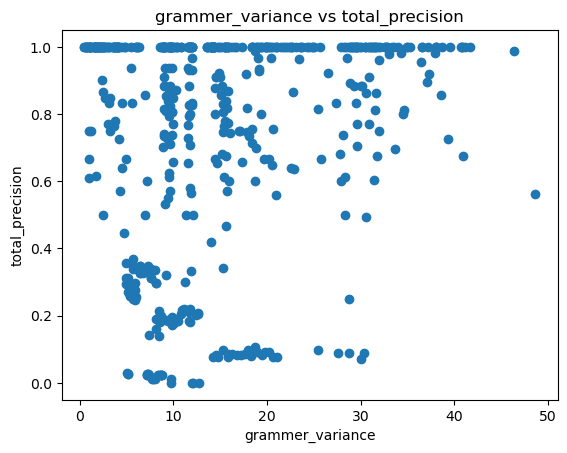

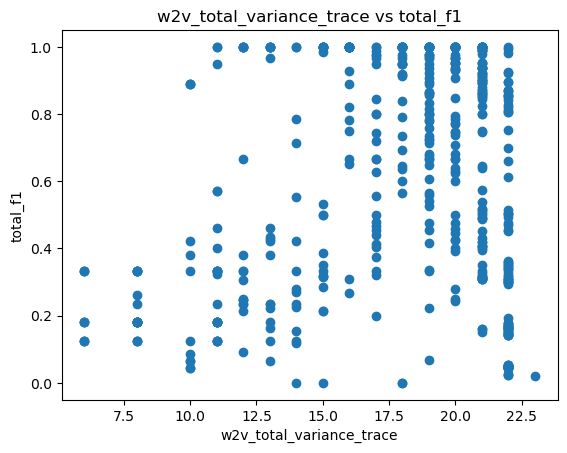

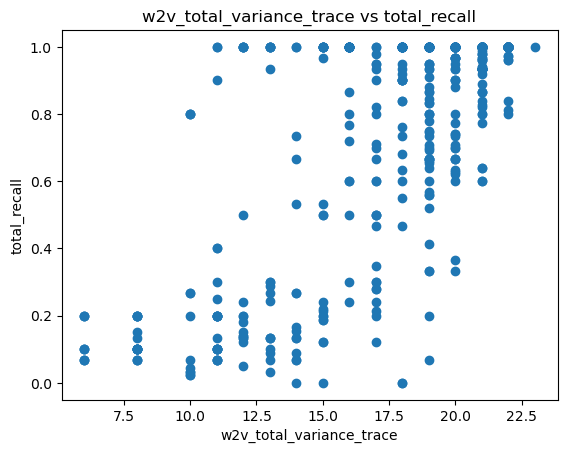

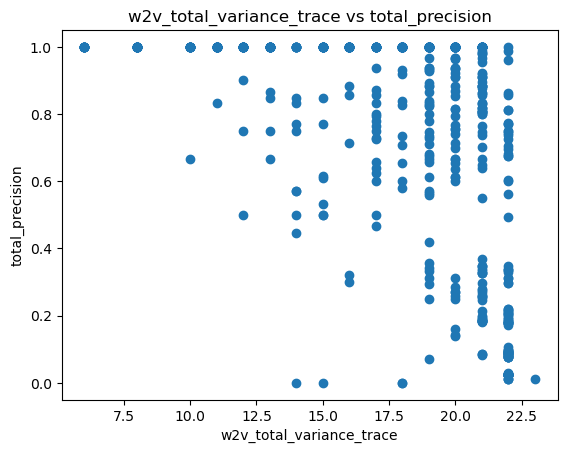

C:\Users\tomho\AppData\Local\Temp\ipykernel_17820\1799587761.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(bins)["total_f1"].mean()


<Axes: xlabel='grammer_variance'>

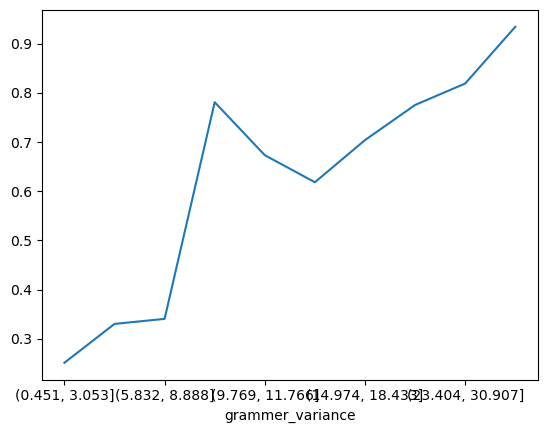

In [30]:
# -------------------------------------------------------------
# Merge the two CSV files on "uiLogName"
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Replace with actual file paths if needed
df_x = pd.read_csv("validation_experiment_results_word2vec_safety2_olap08_rho08_enc0_core08.csv")  # contains f1_score, recall, precision
df_y = pd.read_csv("variance_data.csv")  # contains variance measures

df = pd.merge(df_x, df_y, on="uiLogName", how="inner")

# -------------------------------------------------------------
# Define metrics and variance columns
# -------------------------------------------------------------
metrics = ["total_f1", "total_recall", "total_precision"]

variance_cols = [
    "grammer_variance",
    "w2v_total_variance_trace"
]

# -------------------------------------------------------------
# Compute Pearson and Spearman correlations
# -------------------------------------------------------------
results = []

def compute_corr(x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan
    
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, np.nan, np.nan

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    return pearson_r, pearson_p, spearman_r, spearman_p

results = []

for var in variance_cols:
    for metric in metrics:
        x = df[var].to_numpy()
        y = df[metric].to_numpy()

        pearson_r, pearson_p, spearman_r, spearman_p = compute_corr(x, y)

        results.append({
            "variance_metric": var,
            "performance_metric": metric,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p
        })

corr_df = pd.DataFrame(results)
print(corr_df)

# -------------------------------------------------------------
# Scatter plots (one plot per variance–metric pair)
# No seaborn, no custom colors, no subplots
# -------------------------------------------------------------
for var in variance_cols:
    for metric in metrics:
        plt.figure()
        plt.scatter(df[var], df[metric])
        plt.xlabel(var)
        plt.ylabel(metric)
        plt.title(f"{var} vs {metric}")
        plt.show()

bins = pd.qcut(df["grammer_variance"], q=10, duplicates="drop")
grouped = df.groupby(bins)["total_f1"].mean()

grouped.plot()